# Gibbs Energy of Each Phase at Fixed Composition

It can be useful to compare the Gibbs energies of individual phases at a fixed alloy composition across temperature, for example to understand which phase becomes stable when, or to inspect the relative metastability of competing phases.

This example shows how to compute $G_M(T)$ for each phase in the Al-Mg system at a fixed Mg mole fraction by constructing one `Workspace` per phase.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from pycalphad import Database, Workspace, variables as v

Set up the database, components, and a temperature sweep at fixed composition `X(MG) = 0.3`.

In [2]:
dbf = Database('Al-Mg_Zhong.tdb')
components = ['AL', 'MG', 'VA']
mg_composition = 0.3  # mole fraction

conditions = {
    v.N: 1,
    v.P: 1e5,
    v.T: (300, 2000, 20),
    v.X('MG'): mg_composition,
}

Loop over the phases in the database. For each phase, build a `Workspace` restricted to that single phase so the equilibrium calculation cannot pick a different phase. Plot the Gibbs energy as a function of temperature.

Stoichiometric phases (e.g. `ALMG_BETA` and `ALMG_EPSILON`) only exist at their fixed composition, so they have no valid solution at `X(MG) = 0.3` and are skipped automatically (their curves are all NaN).

Skipping ALMG_BETA: no valid solution at X(MG)=0.3


Skipping ALMG_EPSILON: no valid solution at X(MG)=0.3


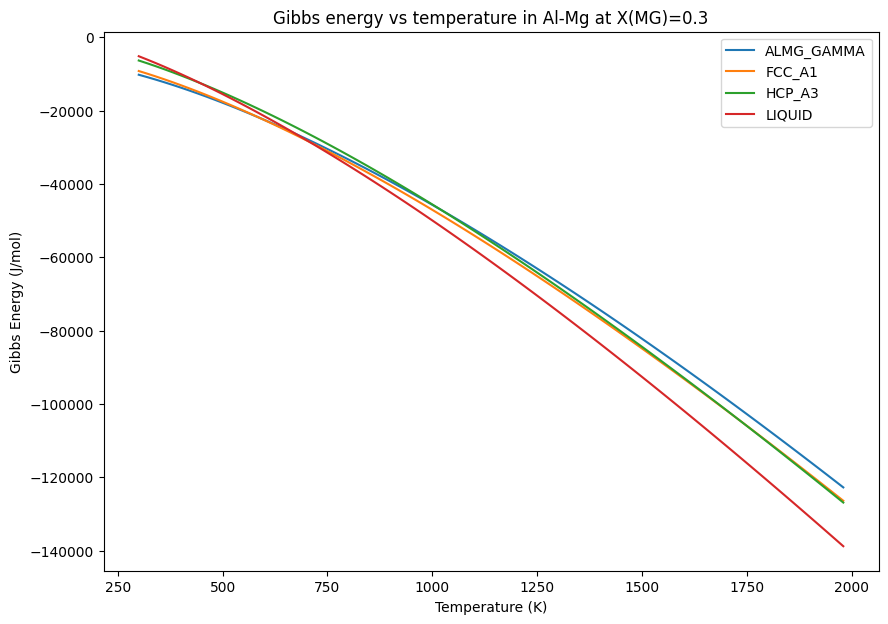

In [3]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 7), dpi=100)
for phase_name in sorted(dbf.phases.keys()):
    wks = Workspace(dbf, components, [phase_name], conditions)
    T = wks.get(v.T)
    GM = wks.get('GM')
    if np.all(np.isnan(GM)):
        print(f'Skipping {phase_name}: no valid solution at X(MG)={mg_composition}')
        continue
    ax.plot(T, GM, label=phase_name)

ax.set_title(f'Gibbs energy vs temperature in Al-Mg at X(MG)={mg_composition}')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Gibbs Energy (J/mol)')
ax.legend(loc='best')